In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')
X_test  = np.load('X_test.npy')
y_test  = np.load('y_test.npy')

with open('feature_scaler.pkl', 'rb') as f:
    feature_scaler = pickle.load(f)

with open('target_scaler.pkl', 'rb') as f:
    target_scaler = pickle.load(f)

with open('feature_columns.pkl', 'rb') as f:
    feature_columns = pickle.load(f)

print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_test shape :', X_test.shape)
print('y_test shape :', y_test.shape)

X_train shape: (2006, 60, 14)
y_train shape: (2006, 1)
X_test shape : (457, 60, 14)
y_test shape : (457, 1)


In [3]:
number_of_features = X_train.shape[2]
model = Sequential()
model.add(LSTM(
    units=64,
    return_sequences=True,
    input_shape=(60, number_of_features)
))

model.add(Dropout(0.2))

model.add(LSTM(
    units=64,
    return_sequences=False
))

model.add(Dropout(0.2))

model.add(Dense(units=1))
model.summary()

C:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model built successfully


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          20,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 53,313 (208.25 KB)

 Trainable params: 53,313 (208.25 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
model.compile(
    optimizer='adam',
    loss='mse'
)

In [5]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True 
)
model_checkpoint = ModelCheckpoint(
    filepath='best_model.keras',  # save to this file
    monitor='val_loss',        # watch validation loss
    save_best_only=True,       # only save when it improves
    verbose=1                  # print a message when it saves
)

In [6]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,                 # maximum number of training rounds
    batch_size=32,             # process 32 samples at a time
    validation_split=0.1,      # use 10% of training data for validation
                               # to monitor overfitting during training
    callbacks=[early_stopping, model_checkpoint],  # use our callbacks
    verbose=1                  # print progress after each epoch
)
print('Total epochs trained:', len(history.history['loss']))

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0089
Epoch 1: val_loss improved from None to 0.00172, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - loss: 0.0089 - val_loss: 0.0017
Epoch 2/50
56/57 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0015
Epoch 2: val_loss did not improve from 0.00172
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0015 - val_loss: 0.0022
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0013
Epoch 3: val_loss improved from 0.00172 to 0.00052, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0013 - val_loss: 5.2103e-04
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0010
Epoch 4: val_loss improved from 0.00052 to 0.00050, saving model to best_model.keras

Epoch 4: finished saving model to best_model.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0010 

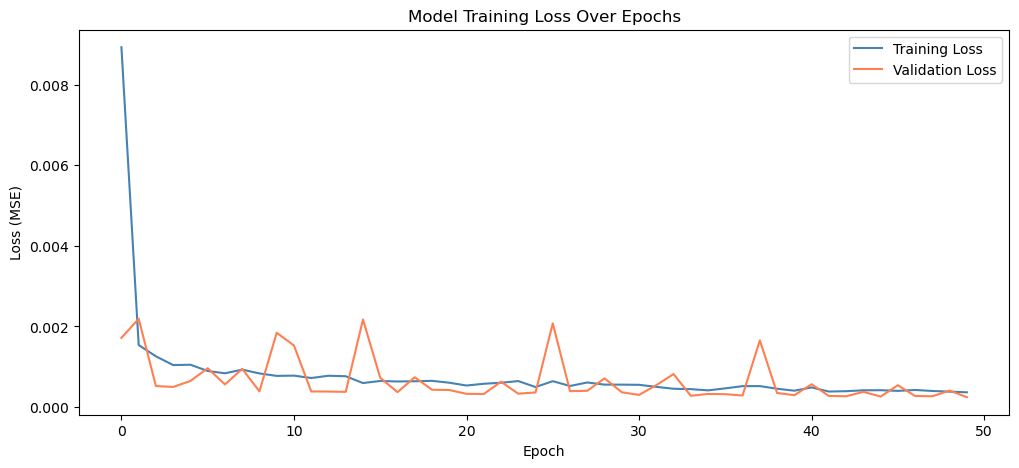

In [7]:
# Plot the training and validation loss over epochs
# This chart tells us if the model learned well or if something went wrong
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], color='steelblue', linewidth=1.5, label='Training Loss')
plt.plot(history.history['val_loss'], color='coral', linewidth=1.5, label='Validation Loss')
plt.title('Model Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

In [8]:
predictions_scaled = model.predict(X_test)
predictions_real = target_scaler.inverse_transform(predictions_scaled)
actual_real = target_scaler.inverse_transform(y_test)
print('First 5 predicted prices:')
for i in range(5):
    print('  Predicted: $' + str(round(predictions_real[i][0], 2)),
          '  |  Actual: $' + str(round(actual_real[i][0], 2)))

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
First 5 predicted prices:
  Predicted: $200.29   |  Actual: $212.45
  Predicted: $203.53   |  Actual: $207.88
  Predicted: $204.86   |  Actual: $205.71
  Predicted: $204.25   |  Actual: $206.35
  Predicted: $203.6   |  Actual: $207.27


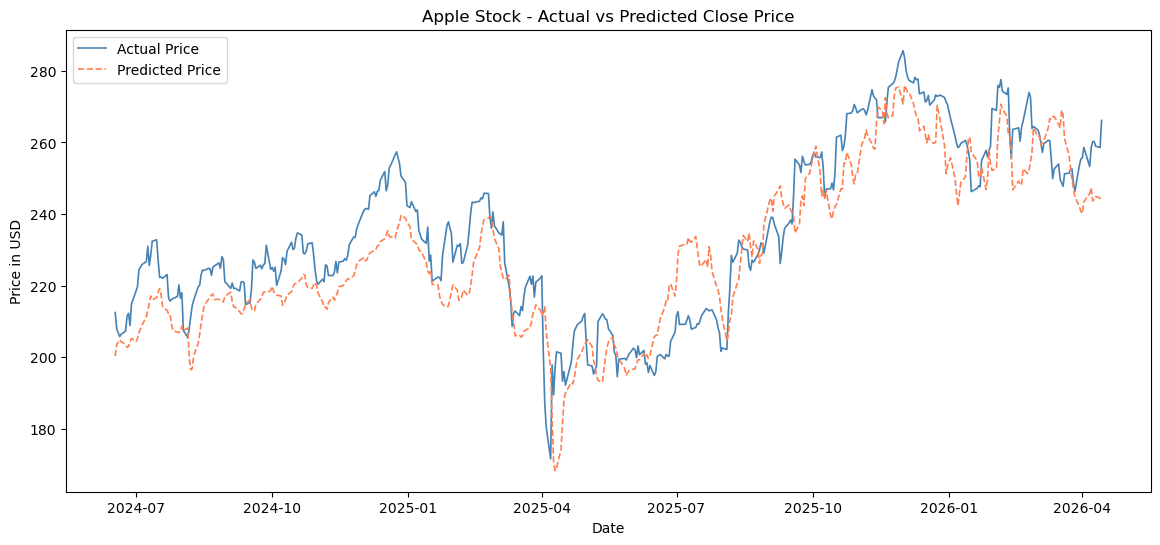

In [9]:
# It shows how well our model predicted the actual stock prices
test_dates = pd.read_csv('final_dataset.csv')
test_dates['date'] = pd.to_datetime(test_dates['date'])
total_rows  = len(test_dates)
train_size  = int(total_rows * 0.80)
test_dates = test_dates['date'].iloc[train_size + 60 :].reset_index(drop=True)

plt.figure(figsize=(14, 6))
plt.plot(test_dates, actual_real, color='steelblue', linewidth=1.2, label='Actual Price')
plt.plot(test_dates, predictions_real, color='coral', linewidth=1.2, label='Predicted Price', linestyle='--')
plt.title('Apple Stock - Actual vs Predicted Close Price')
plt.xlabel('Date')
plt.ylabel('Price in USD')
plt.legend()
plt.show()

In [10]:
# Save the trained model to a file
model.save('lstm_model.keras')